In [1]:
import os, sys, importlib, pathlib
import pandas as pd
from pathlib import Path
sys.path.append (os.path.abspath(".."))
# my utils
from utils import fa
from utils import modeling
from utils import preprocess_listings
from utils.preprocess_listings import desc_catORnum

# 标准版存档V0：

LABELS_EN=[
            'open to different cultures', 'cosmopolitan','international view', 'cultural exchange',
            'personal life', 'life experiences', 'divers interests', 'hobbies', 'enjoy life',
            'meet new people', 'welcoming', 'friendly', 'sociable', 'interpersonal interaction',
            'thoughtful service', 'attentive to needs', 'willing to help', 'responsive',
            'fan of Airbnb', 'Airbnb community','love Airbnb', 'travel with Airbnb'
        ]
DICT_FACTOR_ITEMS={"ouverture":['open to different cultures', 'cosmopolitan','international view', 'cultural exchange'],
                   "authenticité":['personal life', 'life experiences', 'divers interests', 'hobbies', 'enjoy life'],
                   "sociabilité":['meet new people', 'welcoming', 'friendly', 'sociable', 'interpersonal interaction'],
                   "auto_promotion":['thoughtful service', 'attentive to needs', 'willing to help', 'responsive'],
                   "exemplarité":['fan of Airbnb', 'Airbnb community','love Airbnb', 'travel with Airbnb']}


In [52]:
path_df="../data_processed\listings_tactics_bio_vis-paris_london-2306_2406.csv"
df_all=pd.read_csv(path_df)
print(df_all.shape)

C:\Users\yeliu\AppData\Local\Temp\ipykernel_6816\3453220627.py:2: DtypeWarning: Columns (68) have mixed types. Specify dtype option on import or set low_memory=False.
  df_all=pd.read_csv(path_df)


(187851, 124)


In [53]:
# df_all.rename(columns={'len':'text_length'}, inplace=True)
# df_all.to_csv(path_df, index=False)

# host_picture_type=> dummy
df_all["pic_no_person"] = (df_all["host_picture_type"]=="no_person").astype(int)
df_all["pic_pro_style"] = (df_all["host_picture_type"]=="pro_style").astype(int)
df_all["pic_life_style"] = (df_all["host_picture_type"]=="life_style").astype(int)
df_all['host_is_superhost']=df_all['host_is_superhost'].apply(lambda x: 1 if x=="t" else 0)
print(df_all.host_is_superhost.value_counts(dropna=False))
print(df_all[['pic_no_person','pic_pro_style','pic_life_style']].value_counts(dropna=False))

host_is_superhost
0    151581
1     36270
Name: count, dtype: int64
pic_no_person  pic_pro_style  pic_life_style
0              1              0                 67014
               0              1                 56786
1              0              0                 55516
0              0              0                  8535
Name: count, dtype: int64


In [54]:
df_all.columns.to_list()

['id',
 'listing_url',
 'scrape_id',
 'last_scraped',
 'source',
 'name',
 'description',
 'neighborhood_overview',
 'picture_url',
 'host_id',
 'host_url',
 'host_name',
 'host_since',
 'host_location',
 'host_about',
 'host_response_time',
 'host_response_rate',
 'host_acceptance_rate',
 'host_is_superhost',
 'host_thumbnail_url',
 'host_picture_url',
 'host_neighbourhood',
 'host_listings_count',
 'host_total_listings_count',
 'host_verifications',
 'host_has_profile_pic',
 'host_identity_verified',
 'neighbourhood',
 'neighbourhood_cleansed',
 'neighbourhood_group_cleansed',
 'latitude',
 'longitude',
 'property_type',
 'room_type',
 'accommodates',
 'bathrooms',
 'bathrooms_text',
 'bedrooms',
 'beds',
 'amenities',
 'price',
 'minimum_nights',
 'maximum_nights',
 'minimum_minimum_nights',
 'maximum_minimum_nights',
 'minimum_maximum_nights',
 'maximum_maximum_nights',
 'minimum_nights_avg_ntm',
 'maximum_nights_avg_ntm',
 'calendar_updated',
 'has_availability',
 'availability_30

In [55]:
# # DROPNA no pic match?
df=df_all.copy()
print(df[['host_has_profile_pic', 'has_face', 'host_picture_type',"is_smiling"]].value_counts(dropna=False),"\n")
df_dropnoface=df[df["has_face"].notna()]
print(len(df_all),len(df_dropnoface))

host_has_profile_pic  has_face  host_picture_type  is_smiling
t                     0.0       no_person          0.0           55515
                      1.0       pro_style          0.0           37747
                                life_style         0.0           34152
                                pro_style          1.0           29267
                                life_style         1.0           22634
f                     NaN       NaN                NaN            7264
t                     NaN       NaN                NaN            1271
f                     0.0       no_person          0.0               1
Name: count, dtype: int64 

187851 179316


In [56]:
# FILLNQ no pic match?
df=df_all.copy()
df['has_face']=df["has_face"].fillna(0)
df['host_picture_type']=df["host_picture_type"].fillna("no_person")
df['is_smiling']=df["is_smiling"].fillna(0)
df_fillnoface=df.copy()
print(df_fillnoface[['host_has_profile_pic', 'has_face',"host_picture_type",'is_smiling']].value_counts(dropna=False),"\n")
print(len(df_all),len(df))

host_has_profile_pic  has_face  host_picture_type  is_smiling
t                     0.0       no_person          0.0           56786
                      1.0       pro_style          0.0           37747
                                life_style         0.0           34152
                                pro_style          1.0           29267
                                life_style         1.0           22634
f                     0.0       no_person          0.0            7265
Name: count, dtype: int64 

187851 187851


In [57]:
vars_tactics=[
    "ouverture", "authenticité","sociabilité","auto_promotion","exemplarité", 
    "host_picture_type","is_smiling", "smile_score"
    ]
# 统一填0

df_dropnoface[vars_tactics]=df_dropnoface[vars_tactics].fillna(0)
df_fillnoface[vars_tactics]=df_fillnoface[vars_tactics].fillna(0)
print(df_dropnoface[vars_tactics].isna().value_counts(dropna=False))
print(df_fillnoface[vars_tactics].isna().value_counts(dropna=False))

# vars_person=["age_class","gender"]
# df[vars_person]=df[vars_person].fillna('unk')


ouverture  authenticité  sociabilité  auto_promotion  exemplarité  host_picture_type  is_smiling  smile_score
False      False         False        False           False        False              False       False          179316
Name: count, dtype: int64
ouverture  authenticité  sociabilité  auto_promotion  exemplarité  host_picture_type  is_smiling  smile_score
False      False         False        False           False        False              False       False          187851
Name: count, dtype: int64


## ols: y=numeric tactic

In [58]:
importlib.reload(modeling)
from utils.modeling import write_formula,build_model
import statsmodels.api as sm
import statsmodels.formula.api as smf

def p_to_sig(p):
    if p < 0.001: return '***'
    elif p < 0.01: return '**'
    elif p < 0.05: return '*'
    elif p < 0.1: return '.'
    else: return ''
    
    
    
x_vars=["host_identity_verified", "host_has_profile_pic",         
    "review_scores_rating", "has_rating", "number_of_reviews_ltm",
    "years_since_host","professional_host",'host_is_superhost', ##'calculated_host_listings_count',
    # 'status_changed', 'old_host_sp_changed',# "is_changed"
    "lang", "text_length",
    "price",
    "availability_90",#*
    "room_type", "instant_bookable", #'is_within_1km',
]  

tactics_bio=["ouverture", "authenticité","sociabilité","auto_promotion","exemplarité"]
tactics_pic=["host_picture_type","is_smiling"]
group_vars=["in_paris","in_2024"]
            
formula= (" is_smiling~ C(host_identity_verified)  + review_scores_rating + has_rating + number_of_reviews_ltm +"
            "C(host_is_superhost) +"
            "years_since_host + professional_host + "
            "text_length + C(lang) +"
            "price  + availability_90 + C(room_type) + C(instant_bookable) + "
            "in_paris * in_2024"
)
model=smf.ols(formula, data=df_dropnoface).fit(cov_type="HC1")#robust standard errors

summary=model.summary()
print(summary)


# authenticité, sociabilité(r²小), auto_promotion 在jo期间显著积极
# ouverture, exemplarité 不显著

                            OLS Regression Results                            
Dep. Variable:             is_smiling   R-squared:                       0.060
Model:                            OLS   Adj. R-squared:                  0.060
Method:                 Least Squares   F-statistic:                     679.9
Date:                Tue, 31 Mar 2026   Prob (F-statistic):               0.00
Time:                        21:58:38   Log-Likelihood:            -1.0712e+05
No. Observations:              179316   AIC:                         2.143e+05
Df Residuals:                  179295   BIC:                         2.145e+05
Df Model:                          20                                         
Covariance Type:                  HC1                                         
                                     coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
Intercept   

## ols: + y=categorial tactic

In [59]:
importlib.reload(modeling)
from utils.modeling import write_formula,build_model

import statsmodels.api as sm
import statsmodels.formula.api as smf
df=df_dropnoface.copy()
tactics_bio=["ouverture", "authenticité","sociabilité","auto_promotion","exemplarité"]
tactics_pic=['pic_no_person','pic_pro_style','pic_life_style', "is_smiling"]
# tactics_pic=["host_picture_type","is_smiling"]

tactics_vars=tactics_bio+tactics_pic
results=[]

for var in tactics_vars:
    print(f"{var}".center(100,"-"))
    formula= (f" {var}~ C(host_identity_verified)  + review_scores_rating + has_rating + number_of_reviews_ltm +"
                "C(host_is_superhost) + years_since_host + professional_host + "
                "C(lang) + text_length +"
                "price  + availability_90 + C(room_type) + C(instant_bookable) + "
                "in_paris * in_2024"
    )
    model=smf.ols(formula, data=df).fit(cov_type="HC1")#robust standard errors
    
    
    coef = model.params["in_paris:in_2024"]
    se = model.bse["in_paris:in_2024"]
    pval = model.pvalues["in_paris:in_2024"]
    
    results.append({
        "variable": var,
        "coef": coef,
        "se": se,
        "pval": pval,
        "sig": p_to_sig(pval),
        "ci_low": coef - 1.96 * se,
        "ci_high": coef + 1.96 * se
    })

import pandas as pd
results_df = pd.DataFrame(results)
# 只有auth, socio, promo显著变化，且是显著提升！
# 更多选取有人物的头像！更多微笑！

---------------------------------------------ouverture----------------------------------------------
--------------------------------------------authenticité--------------------------------------------
--------------------------------------------sociabilité---------------------------------------------
-------------------------------------------auto_promotion-------------------------------------------
--------------------------------------------exemplarité---------------------------------------------
-------------------------------------------pic_no_person--------------------------------------------
-------------------------------------------pic_pro_style--------------------------------------------
-------------------------------------------pic_life_style-------------------------------------------
---------------------------------------------is_smiling---------------------------------------------


In [60]:
display(results_df)

,variable,coef,se,pval,sig,ci_low,ci_high
0,ouverture,-0.005223,0.006277,4.053602e-01,,-0.017527,0.007080
1,authenticité,0.039962,0.006567,1.160770e-09,***,0.027091,0.052833
2,sociabilité,0.028258,0.006773,3.018110e-05,***,0.014983,0.041533
3,auto_promotion,0.018818,0.006196,2.388646e-03,**,0.006674,0.030963
4,exemplarité,0.007684,0.006392,2.292986e-01,,-0.004844,0.020212
5,pic_no_person,-0.034248,0.004012,1.391829e-17,***,-0.042112,-0.026384
6,pic_pro_style,0.010724,0.004569,1.893120e-02,*,0.001768,0.019680
7,pic_life_style,0.023524,0.004437,1.145520e-07,***,0.014828,0.032220
8,is_smiling,0.043782,0.004268,1.084567e-24,***,0.035417,0.052147


<Figure size 640x480 with 0 Axes>

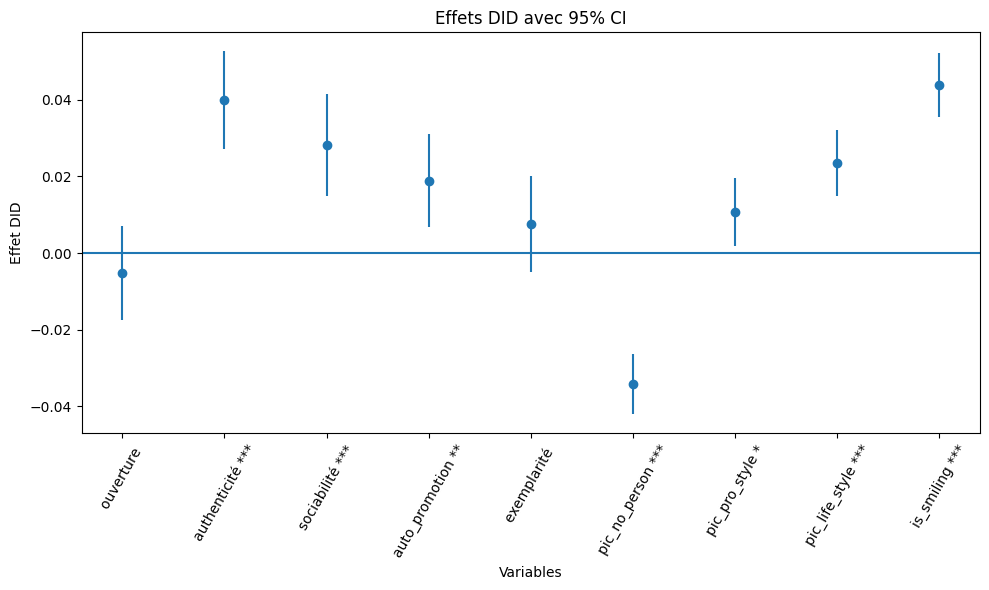

In [62]:
## did effect
import pandas as pd
import matplotlib.pyplot as plt

results_df['label']=results_df['variable']+" "+results_df['sig']

plt.figure()
plt.figure(figsize=(10,6))
plt.errorbar(
    results_df["label"],
    results_df["coef"],
    yerr=[results_df["coef"] - results_df["ci_low"],
          results_df["ci_high"] - results_df["coef"]],
    fmt='o', 
)
plt.axhline(0)  # 0线（是否显著）
plt.xlabel("Variables")
plt.ylabel("Effet DID")
plt.title("Effets DID avec 95% CI")
plt.xticks(rotation=60)
plt.tight_layout()
plt.show()

## ols: y=booking_rate

In [8]:
## q : number_of_reviews_ltm? bad ctrl?

df_dropnoface[['number_of_reviews_ltm','booking_rate_l90d']].describe()

,number_of_reviews_ltm,booking_rate_l90d
count,179316.000000,179316.000000
mean,8.952826,0.133637
std,15.773427,0.238960
min,0.000000,0.000000
25%,0.000000,0.000000
50%,3.000000,0.033333
75%,11.000000,0.140625
max,852.000000,1.000000


In [ ]:
# basic: booking90 ~ ctrl + bio + pic + city*time
importlib.reload(modeling)
from utils.modeling import write_formula,build_model

import statsmodels.api as sm
import statsmodels.formula.api as smf


# C(host_is_superhost)
# C(host_has_profile_pic)

x_vars=["host_identity_verified", "host_has_profile_pic",         
    "review_scores_rating", #"has_rating", "number_of_reviews",
    "years_since_host","professional_host",'host_is_superhost', ##'calculated_host_listings_count',
    # 'status_changed', 'old_host_sp_changed',# "is_changed"
    "lang", "len",
    "price",
    "availability_90",#*
    "room_type", "instant_bookable", #'is_within_1km',
    
    "ouverture", "authenticité","sociabilité","auto_promotion","exemplarité", 
    "host_picture_type","is_smiling"
]  
tactics_vars=["in_paris","in_2024"]

# smile_score coef 过小!

formula= ("booking_rate_l90d ~ C(host_identity_verified)  + review_scores_rating + has_rating + "
            "C(host_is_superhost) + "
            "years_since_host + professional_host + "
            "text_length + C(lang) +"
            "price  + availability_90 + C(room_type) + C(instant_bookable) + "
            "ouverture + authenticité + sociabilité + auto_promotion + exemplarité +"
            "C(host_picture_type) + is_smiling + "
            "in_paris * in_2024"
)
model=smf.ols(formula, data=df_dropnoface).fit()
summary=model.summary()
print(summary)

                            OLS Regression Results                            
Dep. Variable:      booking_rate_l90d   R-squared:                       0.317
Model:                            OLS   Adj. R-squared:                  0.317
Method:                 Least Squares   F-statistic:                     1571.
Date:                Mon, 30 Mar 2026   Prob (F-statistic):               0.00
Time:                        20:38:09   Log-Likelihood:                 15098.
No. Observations:               91337   AIC:                        -3.014e+04
Df Residuals:                   91309   BIC:                        -2.988e+04
Df Model:                          27                                         
Covariance Type:            nonrobust                                         
                                        coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
Interc

In [189]:
## ps.tactics_host* in_paris:in_2024
# R2比不交互时下降

importlib.reload(modeling)
from utils.modeling import write_formula,build_model

import statsmodels.api as sm
import statsmodels.formula.api as smf


# C(host_is_superhost)
# C(host_has_profile_pic)

x_vars=["host_identity_verified", "host_has_profile_pic",         
    "review_scores_rating", #"has_rating", "number_of_reviews",
    "years_since_host","professional_host",'host_is_superhost', ##'calculated_host_listings_count',
    # 'status_changed', 'old_host_sp_changed',# "is_changed"
    "lang", "len",
    "price",
    "availability_90",#*
    "room_type", "instant_bookable", #'is_within_1km',
    
    "ouverture", "authenticité","sociabilité","auto_promotion","exemplarité", 
    "host_picture_type","is_smiling"
]  
tactics_vars=["in_paris","in_2024"]

# smile_score coef 过小!

formula= ("booking_rate_l90d ~ C(host_identity_verified)  + review_scores_rating + has_rating +"
        #   "number_of_reviews_ltm+ "
        "years_since_host + professional_host + "
        "text_length + C(lang) +"
        "price  + availability_90 + C(room_type) + C(instant_bookable) + "
        "(ouverture + authenticité + sociabilité + auto_promotion + exemplarité +C(host_picture_type) + is_smiling + C(host_is_superhost))*(in_paris:in_2024)"
)
model=smf.ols(formula, data=df_dropnoface).fit()
summary=model.summary()
print(summary)

                            OLS Regression Results                            
Dep. Variable:      booking_rate_l90d   R-squared:                       0.314
Model:                            OLS   Adj. R-squared:                  0.314
Method:                 Least Squares   F-statistic:                     1229.
Date:                Mon, 30 Mar 2026   Prob (F-statistic):               0.00
Time:                        21:38:49   Log-Likelihood:                 14879.
No. Observations:               91337   AIC:                        -2.969e+04
Df Residuals:                   91302   BIC:                        -2.936e+04
Df Model:                          34                                         
Covariance Type:            nonrobust                                         
                                                         coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------

In [190]:
# tactics_host* in_paris*in_2024
## ps.# tactics_host* in_paris:in_2024，R2比不交互时下降

importlib.reload(modeling)
from utils.modeling import write_formula,build_model

import statsmodels.api as sm
import statsmodels.formula.api as smf


# C(host_is_superhost)
# C(host_has_profile_pic)

x_vars=["host_identity_verified", "host_has_profile_pic",         
    "review_scores_rating", #"has_rating", "number_of_reviews",
    "years_since_host","professional_host",'host_is_superhost', ##'calculated_host_listings_count',
    # 'status_changed', 'old_host_sp_changed',# "is_changed"
    "lang", "len",
    "price",
    "availability_90",#*
    "room_type", "instant_bookable", #'is_within_1km',
    
    "ouverture", "authenticité","sociabilité","auto_promotion","exemplarité", 
    "host_picture_type","is_smiling"
]  
tactics_vars=["in_paris","in_2024"]

# smile_score coef 过小!

formula= ("booking_rate_l90d ~ C(host_identity_verified)  + review_scores_rating + has_rating +"
        #   "number_of_reviews_ltm+ "
        "years_since_host + professional_host + "
        "text_length + C(lang) +"
        "price  + availability_90 + C(room_type) + C(instant_bookable) + "
        "(ouverture + authenticité + sociabilité + auto_promotion + exemplarité +C(host_picture_type) + is_smiling + C(host_is_superhost))*in_paris*in_2024"
)
model=smf.ols(formula, data=df_dropnoface).fit()
summary=model.summary()
print(summary)

                            OLS Regression Results                            
Dep. Variable:      booking_rate_l90d   R-squared:                       0.323
Model:                            OLS   Adj. R-squared:                  0.323
Method:                 Least Squares   F-statistic:                     806.9
Date:                Mon, 30 Mar 2026   Prob (F-statistic):               0.00
Time:                        21:49:05   Log-Likelihood:                 15494.
No. Observations:               91337   AIC:                        -3.088e+04
Df Residuals:                   91282   BIC:                        -3.036e+04
Df Model:                          54                                         
Covariance Type:            nonrobust                                         
                                                         coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------

## ols : 有number_of_reviews版本，关键变量coef变化不大

In [63]:
x_vars=["host_identity_verified",          
    "review_scores_rating", "has_rating", "number_of_reviews_ltm",
    "host_is_superhost","years_since_host","professional_host", ##'calculated_host_listings_count',
    # 'status_changed', 'old_host_sp_changed',# "is_changed"
    "lang", "text_length",
    "price","availability_90","room_type", "instant_bookable", #'is_within_1km'
    "ouverture", "authenticité","sociabilité","auto_promotion","exemplarité", 
    "host_picture_type",'pic_no_person','pic_pro_style','pic_life_style',
    "is_smiling"
]  


df_dropnoface[x_vars].isna().value_counts(dropna=False)

host_identity_verified  review_scores_rating  has_rating  number_of_reviews_ltm  host_is_superhost  years_since_host  professional_host  lang   text_length  price  availability_90  room_type  instant_bookable  ouverture  authenticité  sociabilité  auto_promotion  exemplarité  host_picture_type  pic_no_person  pic_pro_style  pic_life_style  is_smiling
False                   False                 False       False                  False              False             False              False  False        False  False            False      False             False      False         False        False           False        False              False          False          False           False         179316
Name: count, dtype: int64

In [64]:
# basci model 但ctrl中加上 number_of_reviews_ltm
importlib.reload(modeling)
from utils.modeling import write_formula,build_model

import statsmodels.api as sm
import statsmodels.formula.api as smf


# C(host_is_superhost)
# C(host_has_profile_pic)
# "host_has_profile_pic"

x_vars=["host_identity_verified",          
    "review_scores_rating", "has_rating", "number_of_reviews_ltm",
    "host_is_superhost","years_since_host","professional_host", ##'calculated_host_listings_count',
    # 'status_changed', 'old_host_sp_changed',# "is_changed"
    "lang", "text_length",
    "price","availability_90","room_type", "instant_bookable", #'is_within_1km'
    "ouverture", "authenticité","sociabilité","auto_promotion","exemplarité", 
    "host_picture_type",'pic_no_person','pic_pro_style','pic_life_style',
    "is_smiling"
]  



formula= ("booking_rate_l90d ~ C(host_identity_verified)  + review_scores_rating + has_rating +"
        "number_of_reviews_ltm + "
        "C(host_is_superhost) +"
        "years_since_host + professional_host + "
        "text_length + C(lang) +"
        "price  + availability_90 + C(room_type) + C(instant_bookable) + "
        "ouverture + authenticité + sociabilité + auto_promotion + exemplarité +"
        # "C(host_picture_type) +"
        "pic_no_person + pic_pro_style + pic_life_style +"
        " is_smiling + "
        "in_paris * in_2024"
)

model=smf.ols(formula, data=df_dropnoface).fit()
summary=model.summary()
print(summary)

                            OLS Regression Results                            
Dep. Variable:      booking_rate_l90d   R-squared:                       0.428
Model:                            OLS   Adj. R-squared:                  0.428
Method:                 Least Squares   F-statistic:                     4787.
Date:                Tue, 31 Mar 2026   Prob (F-statistic):               0.00
Time:                        21:59:38   Log-Likelihood:                 52295.
No. Observations:              179316   AIC:                        -1.045e+05
Df Residuals:                  179287   BIC:                        -1.042e+05
Df Model:                          28                                         
Covariance Type:            nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
Intercept   

In [65]:
# interaction model + number_of_reviews_ltm
# tactics_host* in_paris*in_2024

## ps.# tactics_host* in_paris:in_2024，R2比不交互时下降

importlib.reload(modeling)
from utils.modeling import write_formula,build_model

import statsmodels.api as sm
import statsmodels.formula.api as smf


x_vars=["host_identity_verified",          
    "review_scores_rating", "has_rating", "number_of_reviews_ltm",
    "host_is_superhost","years_since_host","professional_host", ##'calculated_host_listings_count',
    # 'status_changed', 'old_host_sp_changed',# "is_changed"
    "lang", "text_length",
    "price","availability_90","room_type", "instant_bookable", #'is_within_1km'
    "ouverture", "authenticité","sociabilité","auto_promotion","exemplarité", 
    "host_picture_type","is_smiling"
]  

# smile_score coef 过小!

formula= ("booking_rate_l90d ~ C(host_identity_verified)  + review_scores_rating + has_rating +"
        "number_of_reviews_ltm+ "
        "years_since_host + professional_host + "
        "text_length + C(lang) +"
        "price  + availability_90 + C(room_type) + C(instant_bookable) + "
        "(ouverture + authenticité + sociabilité + auto_promotion + exemplarité +C(host_picture_type) + is_smiling + C(host_is_superhost))*in_paris*in_2024"
)
model_interaction=smf.ols(formula, data=df_dropnoface).fit()
summary=model_interaction.summary()
print(summary)

                            OLS Regression Results                            
Dep. Variable:      booking_rate_l90d   R-squared:                       0.432
Model:                            OLS   Adj. R-squared:                  0.431
Method:                 Least Squares   F-statistic:                     2475.
Date:                Tue, 31 Mar 2026   Prob (F-statistic):               0.00
Time:                        21:59:50   Log-Likelihood:                 52894.
No. Observations:              179316   AIC:                        -1.057e+05
Df Residuals:                  179260   BIC:                        -1.051e+05
Df Model:                          55                                         
Covariance Type:            nonrobust                                         
                                                         coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------

## effet réel

In [35]:
## 每一组的真实effect
import numpy as np
import pandas as pd
from itertools import product
def p_to_sig(p):
    if p < 0.001: return '***'
    elif p < 0.01: return '**'
    elif p < 0.05: return '*'
    elif p < 0.1: return '.'
    else: return ''
    
    
    
def get_did_marginal_effect(
    model, 
    key_var,
    paris_var="in_paris",
    time_var="in_2024"
):
    """
    计算 key_var 在四个 DID 组中的边际效应
    """
    params = model.params
    param_names = params.index.tolist()

    rows = []

    # 四种组合
    for p, t in product([0,1], [0,1]):
        # 用0,1标注出我们要交互的vars的index:
        lin_comb = np.zeros(len(params))
        # 主效应
        if key_var in param_names:
            lin_comb[param_names.index(key_var)] = 1

        # key_var × paris
        term = f"{key_var}:{paris_var}"
        if term in param_names:
            lin_comb[param_names.index(term)] = p

        # key_var × time
        term = f"{key_var}:{time_var}"
        if term in param_names:
            lin_comb[param_names.index(term)] = t

        # triple interaction
        term = f"{key_var}:{paris_var}:{time_var}"
        if term in param_names:
            lin_comb[param_names.index(term)] = p * t
        # print(lin_comb)
        
        # t-test
        t_res = model.t_test(lin_comb)
        # print(t_res)
        rows.append({
            "in_paris": p,
            "in_2024": t,
            "group": f"{'Paris' if p ==1 else 'London'} {'2024' if t ==1 else '2023'}",
            "coef": float(t_res.effect),
            "se": float(t_res.sd),
            "t": float(t_res.tvalue),
            "pval": float(t_res.pvalue),
            "sig": p_to_sig(float(t_res.pvalue)),            
        })
    result_df= pd.DataFrame(rows)
    result_df['label']=result_df['group']+' '+result_df['sig']
    
    return result_df



var='auto_promotion'
res = get_did_marginal_effect(model, var, paris_var="in_paris", time_var="in_2024")
display(res)


C:\Users\yeliu\AppData\Local\Temp\ipykernel_6816\38004770.py:59: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  "coef": float(t_res.effect),
C:\Users\yeliu\AppData\Local\Temp\ipykernel_6816\38004770.py:60: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  "se": float(t_res.sd),
C:\Users\yeliu\AppData\Local\Temp\ipykernel_6816\38004770.py:61: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  "t": float(t_res.tvalue),


,in_paris,in_2024,group,coef,se,t,pval,sig,label
0,0,0,London 2023,-0.008015,0.001525,-5.257530,1.461696e-07,***,London 2023 ***
1,0,1,London 2024,-0.001541,0.001483,-1.038797,2.989008e-01,,London 2024
2,1,0,Paris 2023,-0.011474,0.001945,-5.898682,3.670710e-09,***,Paris 2023 ***
3,1,1,Paris 2024,0.002650,0.001521,1.742401,8.144001e-02,.,Paris 2024 .


In [36]:

# did = model.params["authenticité:in_paris:in_2024"]
# pval = model.pvalues["authenticité:in_paris:in_2024"]
# title = f"authenticité (DID = {did:.3f}, p={pval:.3f})"

import numpy as np

def get_linear_pval(model, terms):
    """
    terms: dict，例如 {"x":1, "x:z":1}
    """
    # 取出所有变量，初始化为0
    params = model.params.index.tolist()
    L = np.zeros(len(params))
    
    # 输入变量的位置标记为1 (terms={in_paris:1, ...}) 
    for name, weight in terms.items():
        if name in params:
            L[params.index(name)] = weight
    res = model.t_test(L)
    return float(res.effect), float(res.sd), float(res.pvalue),  p_to_sig(float(res.pvalue))


def get_did_summary(model, var, paris_var="in_paris", time_var="in_2024"):
    params = model.params
    cov = model.cov_params()

    def get_coef(name):
        return params[name] if name in params else 0

    def get_var(name):
        return cov.loc[name, name] if name in cov.index else 0
    
    def get_pval(name):
        return params[name, name] if name in params else 0

    # 系数名
    b1 = var
    b2 = f"{var}:{paris_var}"
    b3 = f"{var}:{time_var}"
    b4 = f"{var}:{paris_var}:{time_var}"

    # DID = β4
    # did_coef = get_coef(b4)
    # did_se = (get_var(b4)) ** 0.5
    # did_p=get_pval(b4)
    did_coef, did_se, did_pval, did_sig = get_linear_pval(model, {
        f"{b4}": 1
    })
    
    # London change = β3
    london_coef = get_coef(b3)
    london_se = (get_var(b3)) ** 0.5
    # london_p=get_pval(b3)
    london_coef, london_se, london_pval, london_sig = get_linear_pval(model, {
        f"{b3}": 1
    })
    
    # Paris change = β3 + β4
    # paris_coef = get_coef(b3) + get_coef(b4)      
    # # 简化（忽略cov）
    # paris_se = (get_var(b3) + get_var(b4)) ** 0.5
    
    paris_coef, paris_se, paris_pval, paris_sig = get_linear_pval(model, {
        f"{b3}": 1,
        f"{b4}": 1
    })
    
    
    return pd.DataFrame({
        "type": ["London change", "Paris change", "DID"],
        "coef": [london_coef, paris_coef, did_coef],
        "se": [london_se, paris_se, did_se],
        'pval':[london_pval, paris_pval, did_pval],
        "sig":[london_sig, paris_sig, did_sig],
        # 'label':
        'tactic':var
    })
    
result_did= get_did_summary(model, var)
display(result_did)

C:\Users\yeliu\AppData\Local\Temp\ipykernel_6816\2425658137.py:20: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return float(res.effect), float(res.sd), float(res.pvalue),  p_to_sig(float(res.pvalue))


,type,coef,se,pval,sig,tactic
0,London change,0.006474,0.002072,1.779997e-03,**,auto_promotion
1,Paris change,0.014124,0.002407,4.430637e-09,***,auto_promotion
2,DID,0.007650,0.003175,1.596319e-02,*,auto_promotion


## plot data

In [37]:
# effet réel 
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pandas as pd

tactics_bio = [
    "ouverture", "authenticité","sociabilité",
    "auto_promotion","exemplarité"
]

# ---------- 收集所有结果 ----------
all_results = []
for var in tactics_bio:
    res = get_did_marginal_effect(model, var)
    res["tactic"] = var

    all_results.append(res)
all_results_df=pd.concat(all_results, ignore_index=True)
all_results_df=all_results_df.sort_values(['tactic','in_paris','in_2024'])
tactics_bio = [
    "ouverture", "authenticité", "sociabilité",
    "auto_promotion", "exemplarité"
]

all_results_df = (
    all_results_df
    .assign(tactic=pd.Categorical(all_results_df["tactic"], categories=tactics_bio, ordered=True))
    .sort_values("tactic")
    .reset_index(drop=True)
)
display(all_results_df)


C:\Users\yeliu\AppData\Local\Temp\ipykernel_6816\38004770.py:59: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  "coef": float(t_res.effect),
C:\Users\yeliu\AppData\Local\Temp\ipykernel_6816\38004770.py:60: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  "se": float(t_res.sd),
C:\Users\yeliu\AppData\Local\Temp\ipykernel_6816\38004770.py:61: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  "t": float(t_res.tvalue),
C:\Users\yeliu\AppData\Local\Temp\ipykernel_6816\38004770.

,in_paris,in_2024,group,coef,se,t,pval,sig,label,tactic
0,1,1,Paris 2024,-0.002278,0.001439,-1.583544,1.132994e-01,,Paris 2024,ouverture
1,1,0,Paris 2023,-0.004188,0.001813,-2.309584,2.091231e-02,*,Paris 2023 *,ouverture
2,0,1,London 2024,0.003080,0.001487,2.071815,3.828416e-02,*,London 2024 *,ouverture
3,0,0,London 2023,0.000072,0.001550,0.046728,9.627298e-01,,London 2023,ouverture
4,0,0,London 2023,0.006710,0.001555,4.314710,1.598981e-05,***,London 2023 ***,authenticité
5,0,1,London 2024,0.001491,0.001473,1.012787,3.111632e-01,,London 2024,authenticité
6,1,0,Paris 2023,0.011033,0.001802,6.124017,9.143357e-10,***,Paris 2023 ***,authenticité
7,1,1,Paris 2024,-0.001227,0.001474,-0.832526,4.051131e-01,,Paris 2024,authenticité
8,0,1,London 2024,0.003833,0.001388,2.761072,5.761778e-03,**,London 2024 **,sociabilité
9,0,0,London 2023,0.009242,0.001447,6.386734,1.698783e-10,***,London 2023 ***,sociabilité


In [38]:
display(all_results_df[all_results_df["group"]=="Paris 2024"])
display(all_results_df[all_results_df["group"]=="Paris 2023"])


,in_paris,in_2024,group,coef,se,t,pval,sig,label,tactic
0,1,1,Paris 2024,-0.002278,0.001439,-1.583544,0.113299,,Paris 2024,ouverture
7,1,1,Paris 2024,-0.001227,0.001474,-0.832526,0.405113,,Paris 2024,authenticité
10,1,1,Paris 2024,0.000617,0.001410,0.437228,0.661946,,Paris 2024,sociabilité
12,1,1,Paris 2024,0.002650,0.001521,1.742401,0.081440,.,Paris 2024 .,auto_promotion
16,1,1,Paris 2024,-0.001534,0.001301,-1.178962,0.238415,,Paris 2024,exemplarité


,in_paris,in_2024,group,coef,se,t,pval,sig,label,tactic
1,1,0,Paris 2023,-0.004188,0.001813,-2.309584,2.091231e-02,*,Paris 2023 *,ouverture
6,1,0,Paris 2023,0.011033,0.001802,6.124017,9.143357e-10,***,Paris 2023 ***,authenticité
11,1,0,Paris 2023,0.013657,0.001806,7.560117,4.046104e-14,***,Paris 2023 ***,sociabilité
13,1,0,Paris 2023,-0.011474,0.001945,-5.898682,3.670710e-09,***,Paris 2023 ***,auto_promotion
18,1,0,Paris 2023,0.005264,0.001709,3.080782,2.064889e-03,**,Paris 2023 **,exemplarité


In [39]:
# beta4 pval
results_did=[]
for var in tactics_bio:
    print(var)
    result_did=get_did_summary(model, var)
    results_did.append(result_did)
    
results_did_df=pd.concat(results_did, axis=0)
display(results_did_df)

ouverture
authenticité
sociabilité
auto_promotion
exemplarité


C:\Users\yeliu\AppData\Local\Temp\ipykernel_6816\2425658137.py:20: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return float(res.effect), float(res.sd), float(res.pvalue),  p_to_sig(float(res.pvalue))


,type,coef,se,pval,sig,tactic
0,London change,0.003008,0.002145,1.608174e-01,,ouverture
1,Paris change,0.001909,0.002251,3.963207e-01,,ouverture
2,DID,-0.001098,0.003109,7.239206e-01,,ouverture
0,London change,-0.005219,0.002128,1.420916e-02,*,authenticité
1,Paris change,-0.012260,0.002291,8.699361e-08,***,authenticité
2,DID,-0.007042,0.003126,2.429726e-02,*,authenticité
0,London change,-0.005409,0.001992,6.608185e-03,**,sociabilité
1,Paris change,-0.013040,0.002280,1.075160e-08,***,sociabilité
2,DID,-0.007631,0.003027,1.169252e-02,*,sociabilité
0,London change,0.006474,0.002072,1.779997e-03,**,auto_promotion


## VIS1:点线图

In [72]:
# ## plot one
# res = get_did_marginal_effect(model, key_var="auto_promotion", paris_var="in_paris", time_var="in_2024")
# df_plot = res.copy()
# df_plot = df_plot.sort_values(["in_paris", "in_2024"])

# display(df_plot)
# import matplotlib.pyplot as plt

# plt.figure()

# x = range(len(df_plot))

# plt.errorbar(
#     x,
#     df_plot["coef"],
#     yerr=1.96 * df_plot["se"],
#     fmt='o'
# )

# plt.xticks(
#     x,
#     ["London 2023", "London 2024", "Paris 2023", "Paris 2024"],
#     rotation=20
# )

# plt.axhline(0)

# plt.ylabel("Marginal Effect on Booking Rate")
# plt.title("Effect of [TACTIC] across Groups")

# plt.show()

C:\Users\yeliu\AppData\Local\Temp\ipykernel_6680\1881623394.py:60: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


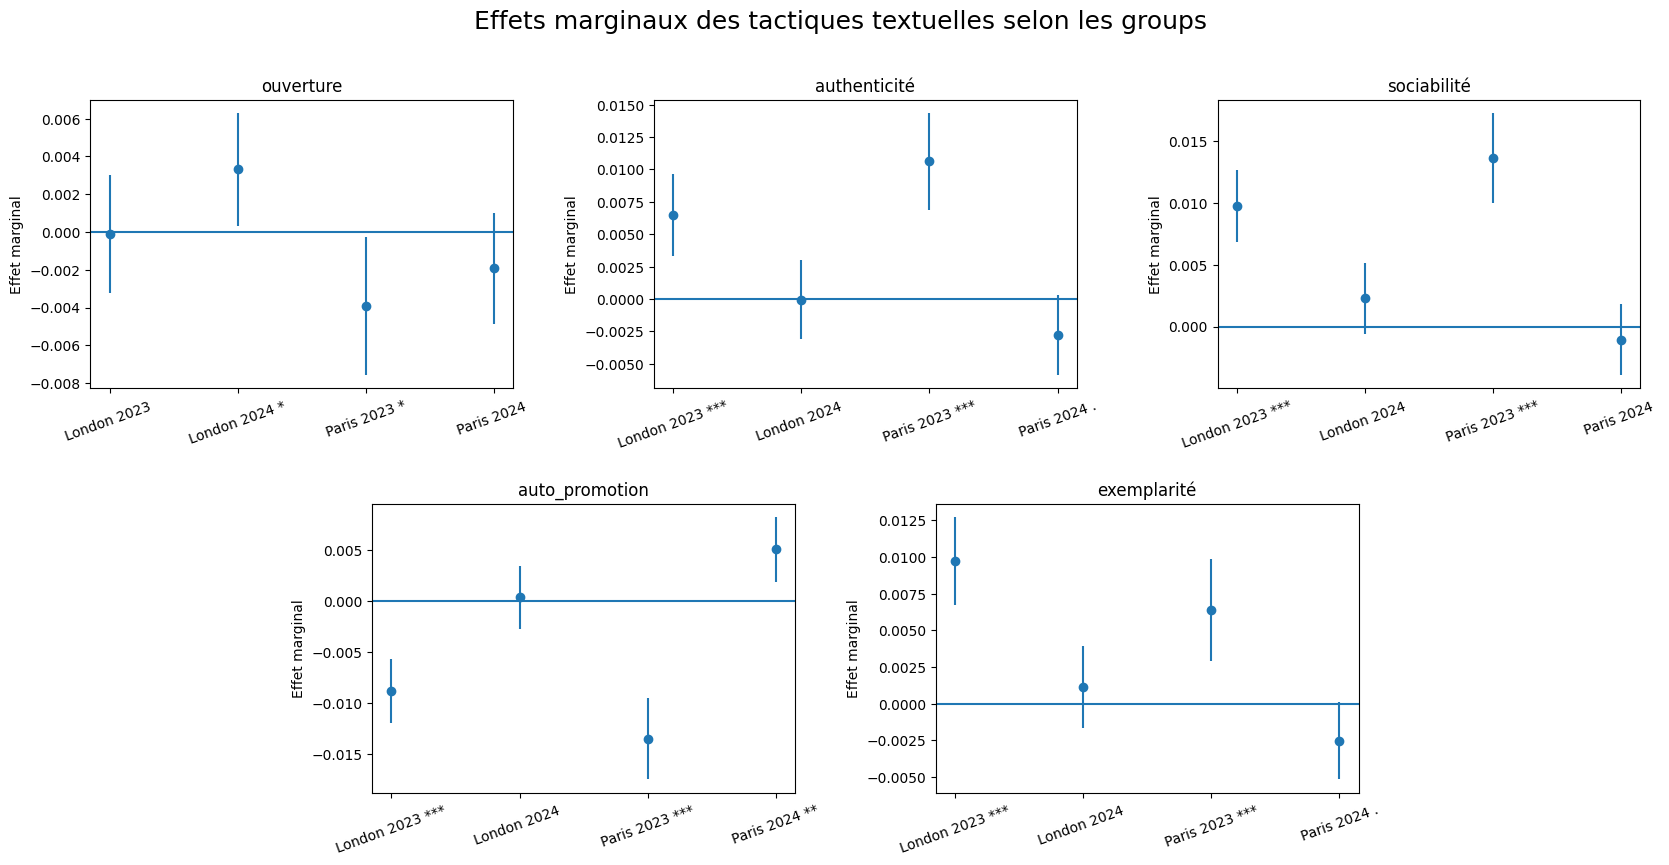

In [61]:
## VIS 1
# plot_df=all_results_df.copy()

# # --------------------layout-------------------
# # 使用更细的列分辨率（2 行 × 6 列），方便把第二行两个图放在中间列
# fig = plt.figure(figsize=(20,9))
# gs = gridspec.GridSpec(2, 6, figure=fig, hspace=0.4, wspace=1)

# axes = []

# # 第一行三个：分别占两列宽 (0:2, 2:4, 4:6)
# ax1 = fig.add_subplot(gs[0, 0:2])
# ax2 = fig.add_subplot(gs[0, 2:4])
# ax3 = fig.add_subplot(gs[0, 4:6])
# axes.extend([ax1, ax2, ax3])

# # 第二行两个：让它们居中，分别占中间的两列 (1:3 和 3:5)
# ax4 = fig.add_subplot(gs[1, 1:3])
# ax5 = fig.add_subplot(gs[1, 3:5])
# axes.extend([ax4, ax5])

# # 确保 tactics_vars 长度为 5（或小于等于 len(axes)）
# n_to_plot = min(len(tactics_vars), len(axes))
    
# group_labels = ["London 2023", "London 2024", "Paris 2023", "Paris 2024"]

# for i, tactic in enumerate(tactics_bio):
#     ax = axes[i]
#     sub = plot_df[plot_df["tactic"] == tactic].sort_values(["in_paris","in_2024"])

#     x = range(4)

#     ax.errorbar(
#         x,
#         sub["coef"],
#         yerr=1.96 * sub["se"],
#         fmt='o'
#     )

#     ax.set_xticks(x)   
#     ax.set_xticklabels(sub['label'], rotation=20)
#     ax.axhline(0)

#     ax.set_title(tactic)
#     ax.set_ylabel("Effet marginal")
    
#     # break 


# fig.suptitle(
#         'Effets marginaux des tactiques textuelles selon les groups',
#         fontsize=18,
#         y=0.98
#     )

# # ---------- 删除第6个空图 ----------
# # fig.delaxes(axes[5])

# # ---------- 调整布局（让第二行居中） ----------
# plt.tight_layout()

# plt.show()

## vis2:折线图

C:\Users\yeliu\AppData\Local\Temp\ipykernel_6816\926332884.py:64: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


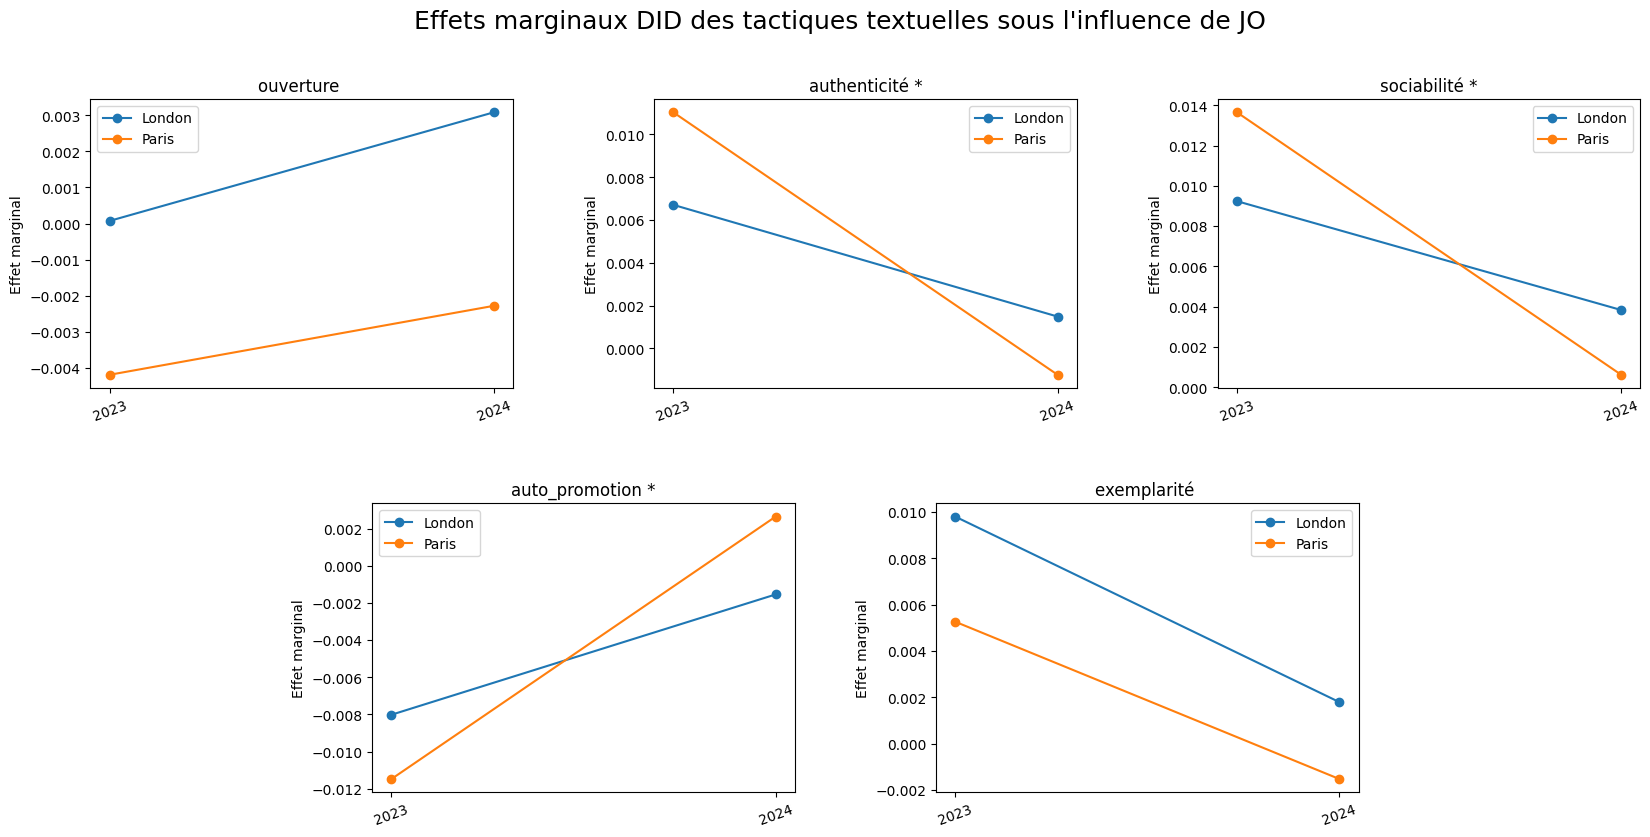

In [67]:
## VIS2: DID 解释因果,策略效果有没有变化
# ps. did可视化，观察不同组效果的差异，而不是一个策略从0-1对于预订率的影响趋势（这种情况采用predict）

plot_df=all_results_df.copy()
# --------------------layout-------------------
# 使用更细的列分辨率（2 行 × 6 列），方便把第二行两个图放在中间列
fig = plt.figure(figsize=(20,9))
gs = gridspec.GridSpec(2, 6, figure=fig, hspace=0.4, wspace=1)

axes = []
# 第一行三个：分别占两列宽 (0:2, 2:4, 4:6)
ax1 = fig.add_subplot(gs[0, 0:2])
ax2 = fig.add_subplot(gs[0, 2:4])
ax3 = fig.add_subplot(gs[0, 4:6])
axes.extend([ax1, ax2, ax3])

# 第二行两个：让它们居中，分别占中间的两列 (1:3 和 3:5)
ax4 = fig.add_subplot(gs[1, 1:3])
ax5 = fig.add_subplot(gs[1, 3:5])
axes.extend([ax4, ax5])

# 确保 tactics_vars 长度为 5（或小于等于 len(axes)）
n_to_plot = min(len(tactics_vars), len(axes))


# ---groups---    
group_labels = ["London 2023", "London 2024", "Paris 2023", "Paris 2024"]

for i, tactic in enumerate(tactics_bio):
    ax = axes[i]
    sub = plot_df[plot_df["tactic"] == tactic].sort_values(["in_paris","in_2024"])
    did_sig=results_did_df[(results_did_df['tactic']==tactic)&(results_did_df["type"]=="DID")]['sig'].iloc[0]

    london = sub[sub["in_paris"]==0]
    ax.plot(
        london["in_2024"],
        london["coef"],
        marker='o',
        label="London"
    )
    # Paris
    paris = sub[sub["in_paris"]==1]
    ax.plot(
        paris["in_2024"],
        paris["coef"],
        marker='o',
        label="Paris"
    )
    
    ax.set_xticks([0,1])
    ax.set_xticklabels(["2023", "2024"], rotation=20)
    ax.set_title(f"{tactic} {did_sig}")
    ax.set_ylabel("Effet marginal")
    ax.legend()


fig.suptitle(
        "Effets marginaux DID des tactiques textuelles sous l'influence de JO",
        fontsize=18,
        y=0.98
    )
# ---------- 调整布局（让第二行居中） ----------
plt.legend()
plt.tight_layout()
plt.show()

##标注斜率是否显著？？
## ouverture, exemplarité的效果没有jo很大影响，和london同趋势发展
# auth和socio被压制
# promo上升


## VIS3 : booking_rate90预测折线图

C:\Users\yeliu\AppData\Local\Temp\ipykernel_6816\3742385218.py:66: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


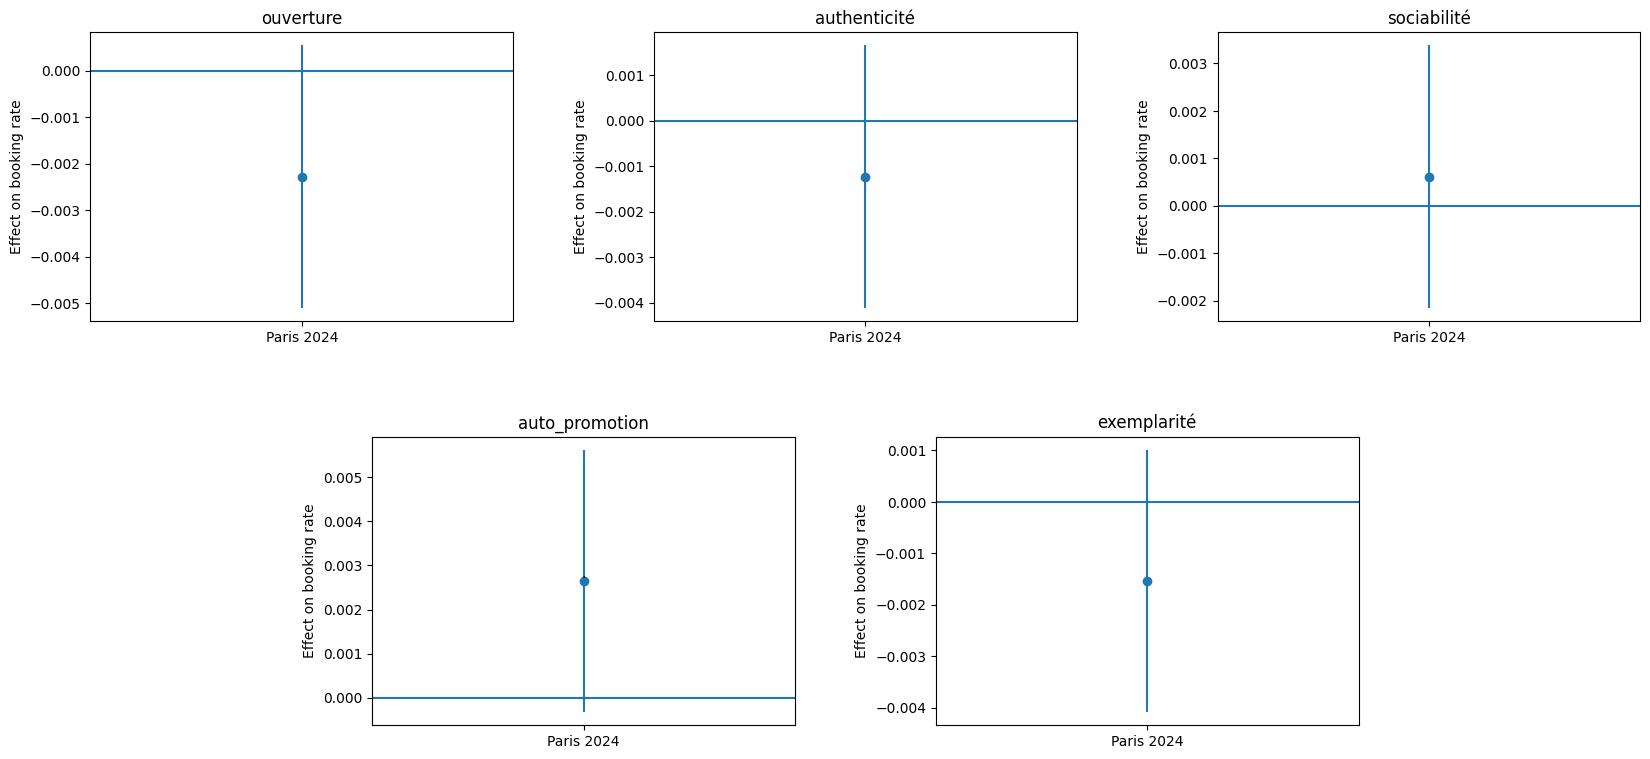

In [41]:
# # 固定时间地点，展示这个策略“实际会带来多少预订变化”
# # Afin d’illustrer l’ampleur économique des effets, nous complétons l’analyse par des courbes de prédiction du taux de réservation.

df_p2024 = all_results_df[
    (all_results_df["in_paris"] == 1) &
    (all_results_df["in_2024"] == 1)
].copy()

import matplotlib.pyplot as plt

tactics_bio = [
    "ouverture", "authenticité","sociabilité",
    "auto_promotion","exemplarité"
]

# --------------------layout-------------------
# 使用更细的列分辨率（2 行 × 6 列），方便把第二行两个图放在中间列
fig = plt.figure(figsize=(20,9))
gs = gridspec.GridSpec(2, 6, figure=fig, hspace=0.4, wspace=1)

axes = []
# 第一行三个：分别占两列宽 (0:2, 2:4, 4:6)
ax1 = fig.add_subplot(gs[0, 0:2])
ax2 = fig.add_subplot(gs[0, 2:4])
ax3 = fig.add_subplot(gs[0, 4:6])
axes.extend([ax1, ax2, ax3])

# 第二行两个：让它们居中，分别占中间的两列 (1:3 和 3:5)
ax4 = fig.add_subplot(gs[1, 1:3])
ax5 = fig.add_subplot(gs[1, 3:5])
axes.extend([ax4, ax5])

# 确保 tactics_vars 长度为 5（或小于等于 len(axes)）
n_to_plot = min(len(tactics_vars), len(axes))


for i, tactic in enumerate(tactics_bio):
    ax = axes[i]
    
    sub = df_p2024[df_p2024["tactic"] == tactic]

    coef = sub["coef"].values[0]
    se = sub["se"].values[0]
    sig = sub["sig"].values[0]

    # 👉 单个点 + CI
    ax.errorbar(
        [0],
        [coef],
        yerr=[1.96 * se],
        fmt='o'
    )

    # 👉 星号
    if sig != "":
        ax.text(0, coef, sig, ha='center', va='bottom')

    ax.axhline(0)
    
    ax.set_xticks([0])
    ax.set_xticklabels(["Paris 2024"])
    
    ax.set_title(tactic)
    ax.set_ylabel("Effect on booking rate")

plt.tight_layout()
plt.show()


In [184]:
for col in model.model.exog_names:
    if not ':' in col and col != 'Intercept':
        print(col)
        

C(host_identity_verified)[T.t]
C(lang)[T.fr]
C(lang)[T.no_text]
C(lang)[T.other_langs]
C(room_type)[T.Hotel room]
C(room_type)[T.Private room]
C(room_type)[T.Shared room]
C(instant_bookable)[T.t]
C(host_picture_type)[T.no_person]
C(host_picture_type)[T.pro_style]
C(host_is_superhost)[T.t]
review_scores_rating
has_rating
number_of_reviews_ltm
years_since_host
professional_host
text_length
price
availability_90
ouverture
authenticité
sociabilité
auto_promotion
exemplarité
is_smiling
in_paris
in_2024


In [42]:
def plot_predict_curve(model, df, tactic, city="paris", time="2024"):
    # default control values
    default_vals = {}
    for col in model.model.exog_names:
        if ':' in col or col == 'Intercept':
            continue
        var_name = col.split('[')[0].replace('C(', '').replace(')', '')
        if var_name in df.columns:
            if df[var_name].dtype == 'O' or df[var_name].nunique() < 10:
                default_vals[var_name] = df[var_name].mode()[0]
            else:
                default_vals[var_name] = df[var_name].mean()
    tactic_range = np.linspace(df[tactic].min(), df[tactic].max(), 100)

    rows = []
    
    for val in tactic_range:
        row = default_vals.copy()
        row[tactic] = val
        row['in_paris'] = 1 if city=="paris" else 0 #
        row['in_2024'] =  1 if time=="2024" else 0#
        rows.append(row)

    pred_df = pd.DataFrame(rows)

    # type alignment
    for col in pred_df.columns:
        if col in df.columns:
            pred_df[col] = pred_df[col].astype(df[col].dtype)

    preds = model.get_prediction(pred_df)
    sf = preds.summary_frame(alpha=0.05)

    pred_df["y"] = sf["mean"]
    pred_df["low"] = sf["mean_ci_lower"]
    pred_df["high"] = sf["mean_ci_upper"]

    return pred_df

C:\Users\yeliu\AppData\Local\Temp\ipykernel_6816\2317312820.py:41: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


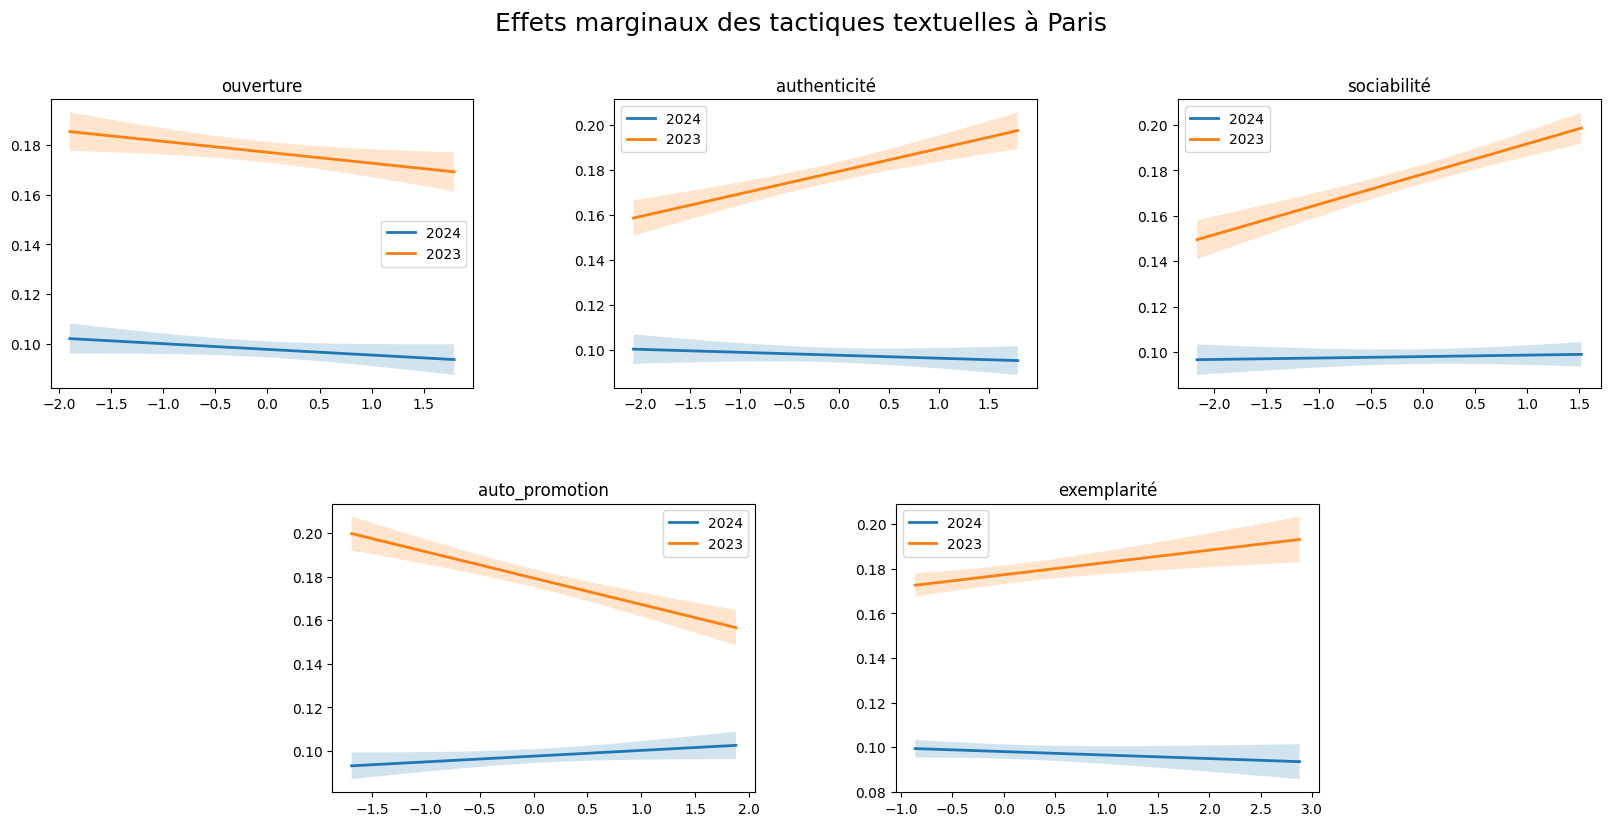

In [66]:
df=df_dropnoface.copy()
model=model_interaction
# -------------------layout-------------------
# 使用更细的列分辨率（2 行 × 6 列），方便把第二行两个图放在中间列
fig = plt.figure(figsize=(20,9))
gs = gridspec.GridSpec(2, 6, figure=fig, hspace=0.4, wspace=1)

axes = []
# 第一行三个：分别占两列宽 (0:2, 2:4, 4:6)
ax1 = fig.add_subplot(gs[0, 0:2])
ax2 = fig.add_subplot(gs[0, 2:4])
ax3 = fig.add_subplot(gs[0, 4:6])
axes.extend([ax1, ax2, ax3])

# 第二行两个：让它们居中，分别占中间的两列 (1:3 和 3:5)
ax4 = fig.add_subplot(gs[1, 1:3])
ax5 = fig.add_subplot(gs[1, 3:5])
axes.extend([ax4, ax5])

# 确保 tactics_vars 长度为 5（或小于等于 len(axes)）
n_to_plot = min(len(tactics_vars), len(axes))


city='paris'
times=['2024',"2023"]
for i, tactic in enumerate(tactics_bio):
    ax = axes[i]
    for time in times:
        pred_df = plot_predict_curve(model, df, tactic, city=city, time=time)
        ax.plot(pred_df[tactic], pred_df["y"], linewidth=2, label=time)
        ax.fill_between(pred_df[tactic], pred_df["low"], pred_df["high"], alpha=0.2)
    ax.legend()#on ax
    ax.set_title(tactic)

fig.suptitle(
        "Effets marginaux des tactiques textuelles à Paris",
        fontsize=18,
        y=0.98
    )

plt.tight_layout()
plt.show()

# tactics_pic


In [ ]:
## VIS3 : tactics_pic
import numpy as np

def get_linear_pval(model, terms_list):
    """
    """    
    # 取出所有变量，初始化为0
    params = model.params.index.tolist()
    L = np.zeros(len(params))
    
    # 输入变量的位置标记为1 (terms={in_paris:1, ...}) 
    for name in terms_list:
        if name in params:
            L[params.index(name)] = 1
    res = model.t_test(L)
    return float(res.effect), float(res.sd), float(res.pvalue),  p_to_sig(float(res.pvalue))


In [89]:
df.host_is_superhost.unique()

array([0, 1])

In [87]:
model=model_interaction
results_cat = []
vars_cat = [
    "C(host_picture_type)[T.no_person]",
    "C(host_picture_type)[T.pro_style]",
    "C(host_picture_type)[T.life_style]",
]

tactics_bio=["ouverture", "authenticité","sociabilité","auto_promotion","exemplarité"]
tactics_pic=['pic_no_person','pic_pro_style','pic_life_style', "is_smiling"]
# tactics_pic=["host_picture_type","is_smiling"]
vars=vars_cat+['is_smiling',"host_is_superhost"]

results=[]
for var in vars:
    coef, se, p, sig = get_linear_pval(
        model,
        [
            var,
            f"{var}:in_paris",
            f"{var}:in_2024",
            f"{var}:in_paris:in_2024"
        ]
    )
    print(var, coef, se, p, sig)
    results_cat.append([var, coef, se, p, sig])
df_results_cat = pd.DataFrame(results_cat, columns=["variable","coef","se","pval","sig"])
display(df_results_cat)


C(host_picture_type)[T.no_person] 0.006370261187354041 0.002216191534761149 0.004048202543942202 **
C(host_picture_type)[T.pro_style] 0.003176631821433384 0.0017633375221899267 0.07162763780373145 .
C(host_picture_type)[T.life_style] 0.0 0.0 1.0 
is_smiling -0.0020625084383483726 0.001765882357675974 0.24281794771166412 
host_is_superhost 0.0 0.0 1.0 


C:\Users\yeliu\AppData\Local\Temp\ipykernel_6816\2631729199.py:17: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return float(res.effect), float(res.sd), float(res.pvalue),  p_to_sig(float(res.pvalue))


,variable,coef,se,pval,sig
0,C(host_picture_type)[T.no_person],0.006370,0.002216,0.004048,**
1,C(host_picture_type)[T.pro_style],0.003177,0.001763,0.071628,.
2,C(host_picture_type)[T.life_style],0.000000,0.000000,1.000000,
3,is_smiling,-0.002063,0.001766,0.242818,
4,host_is_superhost,0.000000,0.000000,1.000000,


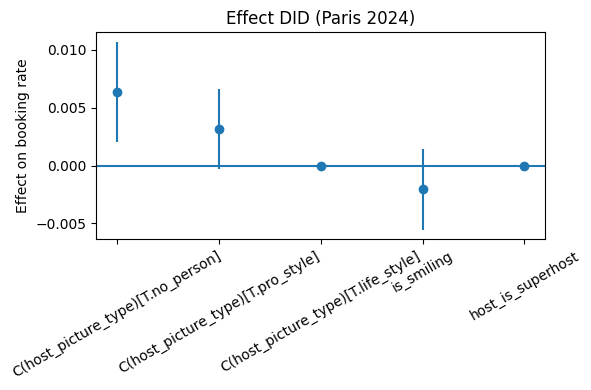

In [88]:
import matplotlib.pyplot as plt
df_pic_did=df_results_cat.copy()

fig, ax = plt.subplots(figsize=(6,4))
x = range(len(df_pic_did))

ax.errorbar(
    x,
    df_pic_did["coef"],
    yerr=1.96 * df_pic_did["se"],
    fmt='o'
)
ax.axhline(0)

ax.set_xticks(x)
ax.set_xticklabels(df_pic_did["variable"], rotation=30)

ax.set_title("Effect DID (Paris 2024)")
ax.set_ylabel("Effect on booking rate") # 
plt.tight_layout()
plt.show()

In [82]:

tactics_pic=[
    "C(host_picture_type)[T.no_person]",
    "C(host_picture_type)[T.pro_style]",
    "C(host_picture_type)[T.life_style]",
    "C(host_is_superhost)[T.t]",
    "is_smiling"
]


# ---------- 收集所有结果 ----------
all_results = []
for var in tactics_pic:
    res = get_did_marginal_effect(model, var)
    res["tactic"] = var

    all_results.append(res)
all_results_df=pd.concat(all_results, ignore_index=True)
all_results_df=all_results_df.sort_values(['tactic','in_paris','in_2024'])

display(all_results_df)


C:\Users\yeliu\AppData\Local\Temp\ipykernel_6816\38004770.py:59: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  "coef": float(t_res.effect),
C:\Users\yeliu\AppData\Local\Temp\ipykernel_6816\38004770.py:60: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  "se": float(t_res.sd),
C:\Users\yeliu\AppData\Local\Temp\ipykernel_6816\38004770.py:61: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  "t": float(t_res.tvalue),
C:\Users\yeliu\AppData\Local\Temp\ipykernel_6816\38004770.

,in_paris,in_2024,group,coef,se,t,pval,sig,label,tactic
12,0,0,London 2023,0.000000,0.000000,0.000000,1.000000e+00,,London 2023,C(host_is_superhost)[T.t]
13,0,1,London 2024,0.000000,0.000000,0.000000,1.000000e+00,,London 2024,C(host_is_superhost)[T.t]
14,1,0,Paris 2023,0.000000,0.000000,0.000000,1.000000e+00,,Paris 2023,C(host_is_superhost)[T.t]
15,1,1,Paris 2024,0.000000,0.000000,0.000000,1.000000e+00,,Paris 2024,C(host_is_superhost)[T.t]
8,0,0,London 2023,0.000000,0.000000,0.000000,1.000000e+00,,London 2023,C(host_picture_type)[T.life_style]
9,0,1,London 2024,0.000000,0.000000,0.000000,1.000000e+00,,London 2024,C(host_picture_type)[T.life_style]
10,1,0,Paris 2023,0.000000,0.000000,0.000000,1.000000e+00,,Paris 2023,C(host_picture_type)[T.life_style]
11,1,1,Paris 2024,0.000000,0.000000,0.000000,1.000000e+00,,Paris 2024,C(host_picture_type)[T.life_style]
0,0,0,London 2023,-0.019903,0.002481,-8.022715,1.040512e-15,***,London 2023 ***,C(host_picture_type)[T.no_person]
1,0,1,London 2024,-0.003322,0.002335,-1.422740,1.548134e-01,,London 2024,C(host_picture_type)[T.no_person]


In [6]:
importlib.reload(modeling)
from utils.modeling import modeling_main,build_model

#-------------------------------vars------------------------------------

x_vars=["host_identity_verified", "host_has_profile_pic",         
    "review_scores_rating", #"has_rating", "number_of_reviews",
    "years_since_host","professional_host",'host_is_superhost', ##'calculated_host_listings_count',
    # 'status_changed', 'old_host_sp_changed',# "is_changed"
    "lang", "len",
    "price",
    "availability_90",#*
    "room_type", "instant_bookable", #'is_within_1km',
    
    "ouverture", "authenticité","sociabilité","auto_promotion","exemplarité", 
    "host_picture_type","is_smiling"
]  
tactics_vars=["is_paris","in_2024"]

modeling_main(df_input=df_all, 
            x_vars=x_vars, 
            y_var="booking_rate_l90d", 
            key_vars=tactics_vars, 
            group_col=None,#"host_is_superhost',#==stauts_changed+sp_changed
            output_folder=None,
            to_fillna0=True,
            run_vif=True,
            # save_models_summary=False,  
            save_models_table=False,
            save_plots=False,
            ndigits=4
        )

=============================================check data=============================================
[INFO] fillna in key cols!`

========================================check output folder=========================================
================================================vif=================================================
+key_vars ; - group_cols
remove key_vars in x_vars
Final x_vars_ctrl :['host_identity_verified', 'host_has_profile_pic', 'review_scores_rating', 'years_since_host', 'professional_host', 'host_is_superhost', 'lang', 'len', 'price', 'availability_90', 'room_type', 'instant_bookable', 'ouverture', 'authenticité', 'sociabilité', 'auto_promotion', 'exemplarité', 'host_picture_type', 'is_smiling']

[INFO] formula :
 booking_rate_l90d ~ C(host_identity_verified) + C(host_has_profile_pic) + C(host_is_superhost) + C(lang) + C(room_type) + C(instant_bookable) + C(host_picture_type) + review_scores_rating + years_since_host + professional_host + len + price + availabilit

,Variables,VIF,Niveau_colinearite
0,Intercept,91561.521721,***
1,C(host_identity_verified)[T.t],1.017968,*
2,C(host_has_profile_pic)[T.t],1.000178,*
3,C(host_is_superhost)[T.t],1.095642,*
4,C(lang)[T.fr],1.926281,*
5,C(lang)[T.no_text],1.008223,*
6,C(lang)[T.other_langs],1.038891,*
7,C(room_type)[T.Hotel room],1.042722,*
8,C(room_type)[T.Private room],1.167226,*
9,C(room_type)[T.Shared room],1.007452,*



 ============================================basic model============================================= 

[NUMBER CHECK1] x_vars:19, x_vars_ctrl:19
['host_identity_verified', 'host_has_profile_pic', 'review_scores_rating', 'years_since_host', 'professional_host', 'host_is_superhost', 'lang', 'len', 'price', 'availability_90', 'room_type', 'instant_bookable', 'ouverture', 'authenticité', 'sociabilité', 'auto_promotion', 'exemplarité', 'host_picture_type', 'is_smiling', 'booking_rate_l90d']
-key_vars ; - group_cols
Final x_vars_ctrl :['host_identity_verified', 'host_has_profile_pic', 'review_scores_rating', 'years_since_host', 'professional_host', 'host_is_superhost', 'lang', 'len', 'price', 'availability_90', 'room_type', 'instant_bookable', 'ouverture', 'authenticité', 'sociabilité', 'auto_promotion', 'exemplarité', 'host_picture_type', 'is_smiling']

[INFO] formula :
 booking_rate_l90d ~ C(host_identity_verified) + C(host_has_profile_pic) + C(host_is_superhost) + C(lang) + C(room_type)

TypeError: 'in <string>' requires string as left operand, not NoneType